In [1]:
pip install pandas matplotlib seaborn scikit-learn tensorflow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('Online Retail.csv')

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
df.dropna(subset=['CustomerID'], inplace=True) 

In [12]:
df['Quantity'].unique()

array([     6,      8,      2,     32,      3,      4,     24,     12,
           48,     18,     20,     36,     80,     64,     10,    120,
           96,     23,      5,      1,     -1,     50,     40,    100,
          192,    432,    144,    288,    -12,    -24,     16,      9,
          128,     25,     30,     28,      7,     72,    200,    600,
          480,     -6,     14,     -2,     -4,     -5,     -7,     -3,
           11,     70,    252,     60,    216,    384,     27,    108,
           52,  -9360,     75,    270,     42,    240,     90,    320,
           17,   1824,    204,     69,    -36,   -192,   -144,    160,
         2880,   1400,     19,     39,    -48,    -50,     56,     13,
         1440,     -8,     15,    720,    -20,    156,    324,     41,
          -10,    -72,    -11,    402,    378,    150,    300,     22,
           34,    408,    972,    208,   1008,     26,   1000,    -25,
         1488,    250,   1394,    400,    110,    -14,     37,    -33,
      

In [13]:
df = df[df['Quantity'] > 0]  # remove returns/refunds

In [14]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [15]:
df['HighPurchase'] = (df['TotalAmount'] > 100).astype(int)


In [34]:
# Select features
features = df[['Quantity', 'UnitPrice', 'Country']]
target = df['HighPurchase']

# One-hot encode Country
features = pd.get_dummies(features, columns=['Country'], drop_first=True)


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, stratify=target, random_state=42)


In [36]:
# Create copies to avoid modifying original data
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale only numerical features
X_train_scaled[['Quantity', 'UnitPrice']] = scaler.fit_transform(X_train[['Quantity', 'UnitPrice']])
X_test_scaled[['Quantity', 'UnitPrice']] = scaler.transform(X_test[['Quantity', 'UnitPrice']])

# Convert to numpy arrays to ensure compatibility with TensorFlow
X_train_scaled = X_train_scaled.values.astype(np.float32)
X_test_scaled = X_test_scaled.values.astype(np.float32)
y_train = y_train.values.astype(np.float32)
y_test = y_test.values.astype(np.float32)

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

c:\Program Files\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/10
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9825 - loss: 0.0755 - val_accuracy: 0.9957 - val_loss: 0.0124
Epoch 2/10
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9825 - loss: 0.0755 - val_accuracy: 0.9957 - val_loss: 0.0124
Epoch 2/10
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 4s 980us/step - accuracy: 0.9962 - loss: 0.0101 - val_accuracy: 0.9971 - val_loss: 0.0093
Epoch 3/10
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 4s 980us/step - accuracy: 0.9962 - loss: 0.0101 - val_accuracy: 0.9971 - val_loss: 0.0093
Epoch 3/10
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 4s 949us/step - accuracy: 0.9971 - loss: 0.0074 - val_accuracy: 0.9974 - val_loss: 0.0090
Epoch 4/10
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 4s 949us/step - accuracy: 0.9971 - loss: 0.0074 - val_accuracy: 0.9974 - val_loss: 0.0090
Epoch 4/10
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 4s 962us/step - accuracy: 0.9974 - loss: 0.0063 - val_accuracy: 0.9972 - val_loss: 0.0070
Epoch 5/10
3980/3980 ━━━━━━━━━━━━━━━━━━━━ 4s 962us/step - accuracy: 0.9974 - los

X_train_scaled shape: (318339, 38)
X_test_scaled shape: (79585, 38)
y_train shape: (318339,)
y_test shape: (79585,)
Model input shape: (None, 38)
2488/2488 ━━━━━━━━━━━━━━━━━━━━ 2s 737us/step - accuracy: 0.9982 - loss: 0.0047
2488/2488 ━━━━━━━━━━━━━━━━━━━━ 2s 737us/step - accuracy: 0.9982 - loss: 0.0047
Test Accuracy: 1.00
Test Accuracy: 1.00


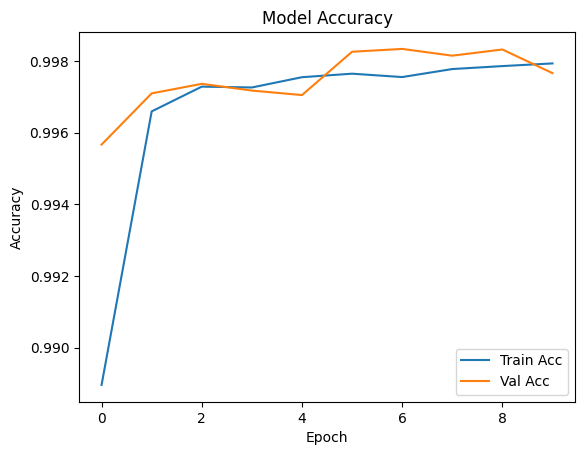

2488/2488 ━━━━━━━━━━━━━━━━━━━━ 2s 601us/step
2488/2488 ━━━━━━━━━━━━━━━━━━━━ 2s 601us/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     77254
         1.0       0.95      0.98      0.97      2331

    accuracy                           1.00     79585
   macro avg       0.98      0.99      0.98     79585
weighted avg       1.00      1.00      1.00     79585

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     77254
         1.0       0.95      0.98      0.97      2331

    accuracy                           1.00     79585
   macro avg       0.98      0.99      0.98     79585
weighted avg       1.00      1.00      1.00     79585



In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Debug: Check shapes
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Model input shape: {model.input_shape}")

# Accuracy - use scaled test data
loss, acc = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {acc:.2f}")

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Predictions - use scaled test data
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))